In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset loaded successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Dataset loaded successfully!
Number of samples: 569
Number of features: 30


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 455
Testing samples: 114


In [ ]:
rng = np.random.RandomState(42)

unlabelled = rng.rand(len(y_train)) < 0.50

y_train_semi = y_train.copy()

# -1 means the sample is unlabelled
y_train_semi[unlabelled] = -1

print("\nLabelled samples:", np.sum(y_train_semi != -1))
print("Unlabelled samples:", np.sum(y_train_semi == -1))


Labelled samples: 235
Unlabelled samples: 220


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
base_model = SVC(
    probability=True,
    kernel="rbf",
    random_state=42
)

model = SelfTrainingClassifier(
    base_model,
    threshold=0.75
)

In [ ]:
model.fit(X_train_scaled, y_train_semi)

print("\nSemi-Supervised Model Training Completed!")


Semi-Supervised Model Training Completed!


In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", round(accuracy * 100, 2), "%")


Model Accuracy: 98.25 %


In [ ]:
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Malignant", "Benign"]
))


Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[41  1]
 [ 1 71]]


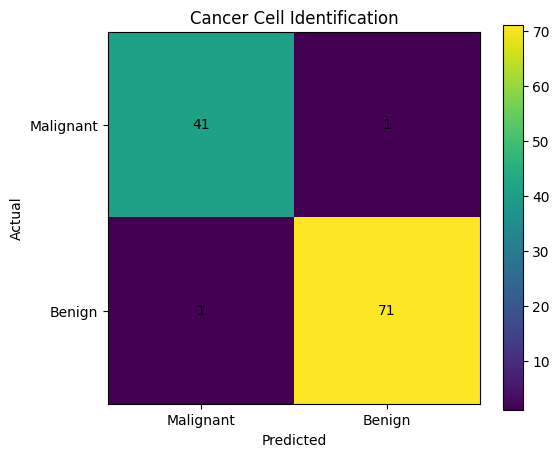

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Cancer Cell Identification")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Malignant", "Benign"])
plt.yticks([0, 1], ["Malignant", "Benign"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.colorbar()
plt.show()

In [ ]:
sample = X_test[0].reshape(1, -1)

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

if prediction[0] == 0:
    print("\nPrediction: MALIGNANT Cancer Cell")
else:
    print("\nPrediction: BENIGN Cell")


Prediction: MALIGNANT Cancer Cell
